# Problem Statement: Build a Smart Mutual Fund Advisor

*On top of the Mutual Funds Report, [sourced](https://www.kaggle.com/datasets/dhavalrupapara/mutual-funds-market-dataset) from Kaggle*

---

## Objective  
Create a Gradio-based AI assistant that recommends a mutual fund investment portfolio based on the user's risk and return preferences. The app uses Retrieval-Augmented Generation (RAG) on a structured Mutual Fund product dataset, generating explainable, structured results.

---

## User App (Essential Features)

### Inputs
- **Investment Needs**: Free-form text input  
  *(e.g., “high return portfolio, only from Aditya Birla fund house”)*
  
### Output
- **Suggestion**: A natural language explanation of what's recommended and why
- **Recommended Mutual Funds**: Structured as a list containing:
  - Scheme Name
  - Fund House
---

## Developer-Facing Advanced Settings

Shown under a collapsible **LLM Settings (Advanced)** section in the UI.

### Model & Generation Settings
- **Model Selector**: *select 2 more open-source / closed-source models*
  - GPT OSS 120B (`gpt-oss-120b`)
- **Temperature Slider**: Adjustable between 0 and 2

These settings allow developers to tune how deterministic or creative the model’s responses are.

---

## Backend Setup

### Vector Store and RAG
- **Embedding Model**: Nomic Embed Text via Ollama, or other model of your choice
- **Vector Database**: ChromaDB, or other vector DB of your choice
- **RAG Workflow**:
  1. Load product catalog using `CSVLoader`
  2. Parse and clean fields into `Document` objects with metadata
  3. Generate embeddings and index documents
  4. Perform similarity search based on user preferences
  5. Use an LLM to generate structured output parsed via `PydanticOutputParser`

# Part 1: Implement the Solution

## Setup

In [1]:
import gradio as gr
import pandas as pd
import os
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_tavily import TavilySearch
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.output_parsers import PydanticOutputParser
from langchain.schema.output_parser import OutputParserException
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from uuid import uuid4
from langgraph.graph import START, StateGraph, END
from typing_extensions import List, TypedDict
from langgraph.checkpoint.memory import MemorySaver

In [2]:
## TODO: Load environment variables and API Keys here
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("OPENROUTER_API_KEY")

## Defining Components

### Chat Model

In [3]:
## TODO: Model name map for UI Mapping
model_name_map = {
    "GPT-OSS-120B": "openai/gpt-oss-120b",
    "Llama 3.3 70B": "meta-llama/llama-3.3-70b-instruct",
    "Gemma 3 27B": "google/gemma-3-27b-it"
}

model_choices = [
    "GPT-OSS-120B",
    "Llama 3.3 70B",
    "Gemma 3 27B"
]

In [57]:
## TODO: Model Selector
def get_llm(model_choice, temperature):

    if model_choice not in model_name_map:
        raise ValueError(
            f"Invalid model: {model_choice}. "
            f"Available models: {list(model_name_map.keys())}"
        )

    return ChatOpenAI(
        model=model_name_map[model_choice],
        temperature=temperature,
        api_key=os.getenv("OPENROUTER_API_KEY"),
        base_url="https://openrouter.ai/api/v1"
    )

### Embedding Model

In [5]:
## TODO: Create embeddings
## Use: OllamaEmbeddings with llama3.2:1b and pull the model beforehand
!ollama pull llama3.2:1b

]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest 
pulling 74701a8c35f6: 100% ▕██████████████████▏ 1.3 GB                         
pulling 966de95ca8a6: 100% ▕██████████████████▏ 1.4 KB                         
pulling fcc5a6bec9da: 100% ▕██████████████████▏ 7.7 KB                         
pulling a70ff7e570d9: 100% ▕██████████████████▏ 6.0 KB                         
pulling 4f659a1e86d7: 100% ▕██████████████████▏  485 B                         
verifying sha256 digest 
writing manifest 
success 


In [6]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)
test = embeddings.embed_query("Hello world")

print(len(test))
print(test[:5])

768
[-0.0066670105, -0.0013420981, -0.17150734, 0.008402206, 0.005851666]


### Vector Store

In [7]:
## TODO: Initialize ChromaDB with a persist directory set
from langchain_chroma import Chroma

vectorstore = Chroma(
    collection_name="my_documents",
    embedding_function=embeddings,
    persist_directory="./chroma_db"
)

In [8]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(
    model="llama3.2:1b"
)

## Load and Preprocess Data

In [9]:
# Load and preprocess data
loader = CSVLoader(file_path="mutual_funds_data.csv", source_column="scheme_code")
documents_raw = loader.load()

In [10]:
# Convert page_content string to dict and build metadata
documents = []
for doc in documents_raw:
    try:
        row_data = dict(
            line.split(":", 1) for line in doc.page_content.split("\n") if ":" in line
        )
        row_data = {k.strip(): v.strip() for k, v in row_data.items()}

        ## TODO: Keep Scheme Name, Fund House, Scheme Type, Scheme Category, Net Asset Value and Date in content
        page_text = (
            f"Scheme Name: {row_data.get('scheme_name', '')}\n"
            f"Fund House: {row_data.get('fund_house', '')}\n"
            f"Scheme Type: {row_data.get('scheme_type', '')}\n"
            f"Scheme Category: {row_data.get('scheme_category', '')}\n"
            f"Net Asset Value: {row_data.get('net_asset_value', '')}\n"
            f"Date: {row_data.get('date', '')}"
        )

        ## TODO: Keep Scheme Type, Scheme Category in metadata
        metadata = {
            "Scheme Type": row_data.get("scheme_type", ""),
            "Scheme Category": row_data.get("scheme_category", "")
        }

        documents.append(Document(page_content=page_text, metadata=metadata))

    except Exception as e:
        print("Skipping row due to error:", e)

In [11]:
len(documents)

35559

In [12]:
print(documents[0].page_content)

Scheme Name: Grindlays Super Saver Income Fund-GSSIF-Half Yearly Dividend
Fund House: Standard Chartered Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Income
Net Asset Value: 10.7205
Date: 29-05-2008


In [13]:
len(documents)

35559

In [14]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)

In [15]:
test = embeddings.embed_query("Hello world")

print(len(test))
print(test[:5])

768
[-0.0066670105, -0.0013420981, -0.17150734, 0.008402206, 0.005851666]


In [16]:
!ollama pull nomic-embed-text

]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest 
pulling 970aa74c0a90: 100% ▕██████████████████▏ 274 MB                         
pulling c71d239df917: 100% ▕██████████████████▏  11 KB                         
pulling ce4a164fc046: 100% ▕██████████████████▏   17 B                         
pulling 31df23ea7daa: 100% ▕██████████████████▏  420 B                         
verifying sha256 digest 
writing manifest 
success 


In [ ]:
!ollama

Ollama 0.34.2                                       
                                                    
▸ Launch Claude Code                                
    Anthropic's coding tool with subagents          
                                                    
  Launch OpenCode (install)                         
    Anomaly's open-source coding agent              
                                                    
  Launch Hermes Agent (install)                     
    Self-improving AI agent built by Nous Research  
                                                    
  Launch OpenClaw (install)                         
    Personal AI with 100+ skills                    
                                                    
  Launch ChatGPT (not installed)                    
    Use Ollama models in ChatGPT                    
                                                    
  More...                                           
    Show additional integrations              

## Store in Vector DB

In [17]:
import uuid

documents_to_store = documents[:1000]

batch_size = 10

for i in range(0, len(documents_to_store), batch_size):

    batch = documents_to_store[i:i + batch_size]

    batch_ids = [
        str(uuid.uuid4())
        for _ in batch
    ]

    vectorstore.add_documents(
        documents=batch,
        ids=batch_ids
    )

    print(f"Added {i + len(batch)} / {len(documents_to_store)}")


Added 10 / 1000
Added 20 / 1000
Added 30 / 1000
Added 40 / 1000
Added 50 / 1000
Added 60 / 1000
Added 70 / 1000
Added 80 / 1000
Added 90 / 1000
Added 100 / 1000
Added 110 / 1000
Added 120 / 1000
Added 130 / 1000
Added 140 / 1000
Added 150 / 1000
Added 160 / 1000
Added 170 / 1000
Added 180 / 1000
Added 190 / 1000
Added 200 / 1000
Added 210 / 1000
Added 220 / 1000
Added 230 / 1000
Added 240 / 1000
Added 250 / 1000
Added 260 / 1000
Added 270 / 1000
Added 280 / 1000
Added 290 / 1000
Added 300 / 1000
Added 310 / 1000
Added 320 / 1000
Added 330 / 1000
Added 340 / 1000
Added 350 / 1000
Added 360 / 1000
Added 370 / 1000
Added 380 / 1000
Added 390 / 1000
Added 400 / 1000
Added 410 / 1000
Added 420 / 1000
Added 430 / 1000
Added 440 / 1000
Added 450 / 1000
Added 460 / 1000
Added 470 / 1000
Added 480 / 1000
Added 490 / 1000
Added 500 / 1000
Added 510 / 1000
Added 520 / 1000
Added 530 / 1000
Added 540 / 1000
Added 550 / 1000
Added 560 / 1000
Added 570 / 1000
Added 580 / 1000
Added 590 / 1000
Added 

In [18]:
for i, doc in enumerate(documents[:5]):
    try:
        result = embeddings.embed_query(doc.page_content)
        print(f"Document {i}: OK - {len(result)} dimensions")
    except Exception as e:
        print(f"Document {i}: FAILED")
        print(e)

Document 0: OK - 768 dimensions
Document 1: OK - 768 dimensions
Document 2: OK - 768 dimensions
Document 3: OK - 768 dimensions
Document 4: OK - 768 dimensions


In [19]:
print(documents[0].page_content)

test_embedding = embeddings.embed_query(
    documents[0].page_content
)

print("Embedding created successfully!")
print(len(test_embedding))

Scheme Name: Grindlays Super Saver Income Fund-GSSIF-Half Yearly Dividend
Fund House: Standard Chartered Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Income
Net Asset Value: 10.7205
Date: 29-05-2008
Embedding created successfully!
768


In [20]:
print(documents_raw[0].page_content)

scheme_code: 100027
scheme_name: Grindlays Super Saver Income Fund-GSSIF-Half Yearly Dividend
fund_house: Standard Chartered Mutual Fund
scheme_type: Open Ended Schemes
scheme_category: Income
net_asset_value: 10.7205
date: 29-05-2008


## Initializing for RAG

### Initialize Retriever

In [21]:
## TODO: Initializer Retriever below
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 5}
)

In [22]:
results = retriever.invoke(
    "What is the NAV of Grindlays Super Saver Income Fund?"
)

for doc in results:
    print(doc.page_content)
    print("---")

Scheme Name: Grindlays Super Saver Income Fund-GSSIF - ST-Dividend
Fund House: Standard Chartered Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Income
Net Asset Value: 10.1053
Date: 29-05-2008
---
Scheme Name: Grindlays Super Saver Income Fund-GSSIF - ST-Dividend
Fund House: Standard Chartered Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Income
Net Asset Value: 10.1053
Date: 29-05-2008
---
Scheme Name: Grindlays Super Saver Income Fund-GSSIF - ST-Dividend
Fund House: Standard Chartered Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Income
Net Asset Value: 10.1053
Date: 29-05-2008
---
Scheme Name: Grindlays Super Saver Income Fund-GSSIF - ST-Dividend
Fund House: Standard Chartered Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Income
Net Asset Value: 10.1053
Date: 29-05-2008
---
Scheme Name: Grindlays Super Saver Income Fund-GSSIF-Quaterly Dividend
Fund House: Standard Chartered Mutual Fund
Scheme Type: Open Ended Schemes
Scheme

### Define Pydantic Schema

In [23]:
## TODO: Define Pydantic schema with type and description
from pydantic import BaseModel, Field
from typing import List

class MutualFund(BaseModel):
    scheme_name: str = Field(description="Name of the mutual fund scheme")
    fund_house: str = Field(description="Name of the mutual fund house")
    scheme_type: str = Field(description="Type of the mutual fund scheme")
    scheme_category: str = Field(description="Category of the mutual fund scheme")


class MutualFundOutput(BaseModel):
    reasoning: str = Field(
        description="Reasoning used to identify the relevant mutual fund schemes"
    )
    schemes: List[MutualFund] = Field(
        description="List of relevant mutual fund schemes"
    )


parser = PydanticOutputParser(
    pydantic_object=MutualFundOutput
)

### Define Prompt

In [24]:
## TODO: Use ChatPromptTemplate.from_template with fields: preferences, context, format_instructions. 
## Make sure no two selected mutual fund schemes fall under the same fund house AND scheme type.
from langchain_core.prompts import ChatPromptTemplate

template = ChatPromptTemplate.from_template("""
You are a mutual fund recommendation assistant.

Based on the user's preferences and the provided mutual fund context, identify the most relevant mutual fund schemes.

User Preferences:
{preferences}

Mutual Fund Context:
{context}

{format_instructions}

Important rules:
- Select only mutual fund schemes supported by the provided context.
- No two selected schemes should belong to the same fund house.
- No two selected schemes should have the same scheme type.
- Do not invent or modify any mutual fund information.
- Return the answer in the exact format specified by the format instructions.
""")

## Creating RAG Pipeline

### Test RAG Pipeline Manually

In [25]:
from langchain_openai import ChatOpenAI
preference = "I want a low risk investment portfolio."

# Retrieve relevant funds
context_docs = retriever.invoke(preference)

# Join the retrieved funds into one piece of text
relevant_text = "\n\n".join(
    doc.page_content for doc in context_docs
)

# Get LLM
llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    temperature=0,
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1"
)

# Create Runnable Sequence
chain = template | llm | parser

# Create input dictionary
input_dict = {
    "preferences": preference,
    "context": relevant_text,
    "format_instructions": parser.get_format_instructions()
}

# Invoke chain
result = chain.invoke(input_dict)

# Convert Pydantic object to dictionary
result = result.model_dump()

print(result)

{'reasoning': 'The user wants a low risk investment portfolio. Among the provided funds, the Sundaram Short Term Credit Risk Fund -Dividend is a debt scheme (Credit Risk Fund) which generally carries lower risk compared to equity funds. Therefore, it is the most suitable choice for a low‑risk profile. No other fund meets the low‑risk criterion without violating the constraints on fund house and scheme type.', 'schemes': [{'scheme_name': 'Sundaram Short Term Credit Risk Fund -Dividend', 'fund_house': 'Sundaram Mutual Fund', 'scheme_type': 'Open Ended Schemes', 'scheme_category': 'Debt Scheme - Credit Risk Fund'}]}


In [ ]:
%pip install langchain-openai

Note: you may need to restart the kernel to use updated packages.


### Define RAG Pipeline Function

In [26]:
def generate_portfolio(model_choice, user_input):
    # Retrieve relevant funds
    context_docs = retriever.invoke(user_input)

    # Join the retrieved funds
    relevant_funds = "\n\n".join(
        doc.page_content for doc in context_docs
    )

    # Get the LLM
    llm = ChatOpenAI(
        model=model_name_map[model_choice],
        temperature=0,
        api_key=os.getenv("OPENROUTER_API_KEY"),
        base_url="https://openrouter.ai/api/v1"
    )

    # Invoking
    chain = template | llm

    output = chain.invoke({
        "preferences": user_input,
        "context": relevant_funds,
        "format_instructions": parser.get_format_instructions()
    })

    # Exception Handling
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None

    return result

## User Interface

In [27]:
def gradio_interface(preferences, model_choice, temperature):

    result = generate_portfolio(
        model_choice,
        preferences,
        temperature
    )

    if not result or isinstance(result, str):
        return result, ""

    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [28]:
# ============================================
# GENERATE PORTFOLIO
# ============================================

def generate_portfolio(model_choice, user_input, temperature):

    try:
        # 1. Retrieve relevant mutual funds
        context_docs = retriever.invoke(user_input)

        # 2. Combine retrieved documents
        relevant_funds = "\n\n".join(
            doc.page_content for doc in context_docs
        )

        # 3. Create the LLM
        llm = ChatOpenAI(
            model=model_name_map[model_choice],
            temperature=temperature,
            api_key=os.getenv("OPENROUTER_API_KEY"),
            base_url="https://openrouter.ai/api/v1"
        )

        # 4. Create chain
        chain = template | llm

        # 5. Send request to LLM
        output = chain.invoke({
            "preferences": user_input,
            "context": relevant_funds,
            "format_instructions": parser.get_format_instructions()
        })

        # 6. Parse LLM response
        result = parser.parse(output.content)

        return result

    except OutputParserException:
        return "Could not parse the LLM output."

    except Exception as e:
        print("Error:", e)
        return f"Error generating portfolio: {str(e)}"


# ============================================
# GRADIO INTERFACE
# ============================================

def gradio_interface(preferences, model_choice, temperature):

    result = generate_portfolio(
        model_choice,
        preferences,
        temperature
    )

    # If an error occurred
    if isinstance(result, str):
        return result, ""

    # Create recommended fund list
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output


# ============================================
# GRADIO UI
# ============================================

with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:

    gr.Markdown("## Smart Mutual Fund Advisor")

    gr.Markdown(
        "Enter your investment preferences and let AI suggest a portfolio!"
    )

    # User preferences
    with gr.Row():

        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    # LLM settings
    with gr.Accordion("LLM Settings (Advanced)", open=False):

        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )

        temperature_slider = gr.Slider(
            minimum=0.0,
            maximum=2.0,
            value=0.7,
            step=0.1,
            label="Temperature"
        )

    # Button
    run_button = gr.Button("Generate Portfolio")

    # Reasoning
    with gr.Row():

        reasoning_output = gr.Textbox(
            label="Remarks",
            lines=2
        )

    # Recommended funds
    with gr.Row():

        fund_list_output = gr.Textbox(
            label="Recommended Mutual Funds",
            lines=10
        )

    # Connect button
    run_button.click(
        fn=gradio_interface,
        inputs=[
            preferences_input,
            model_dropdown,
            temperature_slider
        ],
        outputs=[
            reasoning_output,
            fund_list_output
        ]
    )


# ============================================
# LAUNCH
# ============================================

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [29]:
from dotenv import load_dotenv
import os

load_dotenv()

print("OPENROUTER_API_KEY loaded:",
      bool(os.getenv("OPENROUTER_API_KEY")))

OPENROUTER_API_KEY loaded: True


In [ ]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/Users/jinalishah/generative-ai-pgp-ji-2026/.venv/lib/python3.13/site-packages/gradio/queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "/Users/jinalishah/generative-ai-pgp-ji-2026/.venv/lib/python3.13/site-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<11 lines>...
    )
    ^
  File "/Users/jinalishah/generative-ai-pgp-ji-2026/.venv/lib/python3.13/site-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<8 lines>...
    )
    ^
  File "/Users/jinalishah/generative-ai-pgp-ji-2026/.venv/lib/python3.13/site-packages/gradio/blocks.py", line 1702, in call_function
    prediction = await anyio.to_thread.run_sync

# Part 2: Implement the RAG pipeline in LangGraph

## Creating Graph

### Define State Class

In [46]:
## TODO: Define State class with preferences, context and answer keys
class State(TypedDict):
    preferences: str
    context: str
    answer: str

### Define Nodes

In [47]:
## TODO: Define retrieve node
def retrieve(state: State):
    relevant_funds = retriever.invoke(state["preferences"])

    context = "\n\n".join(
        doc.page_content for doc in relevant_funds
    )

    return {"context": context}

In [48]:
## TODO: Define generate node
def generate(state: State):
     # Join the retrieved mutual funds
    relevant_funds_str = state["context"]

    # Create Runnable Sequence
    chain = template | llm_graph

    # Invoke the chain
    output = chain.invoke({
        "preferences": state["preferences"],
        "context": relevant_funds_str,
        "format_instructions": parser.get_format_instructions()
    })

    # Exception Handling for Output Parser
    try:
        result = parser.parse(output.content)

    except OutputParserException:
        return {"answer": "Could not parse output."}

    # Return only the answer part of the state
    return {"answer": result}

### Build and Compile Graph

In [49]:
## TODO: Build the graph with 2 nodes and 3 edges
from langgraph.graph import StateGraph, START, END

# Create the graph builder
graph_builder = StateGraph(State)

# Add nodes
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate_answer", generate)

# Add edges
graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate_answer")
graph_builder.add_edge("generate_answer", END)

In [50]:
#Compile graph
graph = graph_builder.compile()

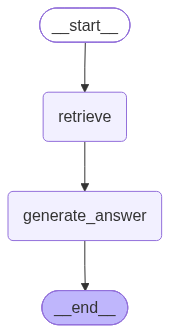

In [51]:
#Visualize graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Test Manually

In [52]:
preferences = "I want a low risk investment portfolio."

# Get LLM
llm_graph = ChatOpenAI(
    model=model_name_map["GPT-OSS-120B"],
    temperature=0,
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1"
)

# Invoke the graph
result = graph.invoke({
    "preferences": preferences,
    "context": "",
    "answer": ""
})

print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend
Fund House: Sundaram Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Debt Scheme - Credit Risk Fund
Net Asset Value: 11.3002
Date: 29-12-2020

Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend
Fund House: Sundaram Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Debt Scheme - Credit Risk Fund
Net Asset Value: 11.3002
Date: 29-12-2020

Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend
Fund House: Sundaram Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Debt Scheme - Credit Risk Fund
Net Asset Value: 11.3002
Date: 29-12-2020

Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend
Fund House: Sundaram Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Debt Scheme - Credit Risk Fund
Net Asset Value: 11.3002
Date: 29-12-2020

Scheme Name: quant Small Cap Fund - IDCW Option - Regular Plan
Fund House: quant Mutual Fund
Scheme Type: Open Ended Schemes
Sc

## User Interface

In [58]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    llm_graph = get_llm(user_input["model_choice"], user_input["temperature"])
    result = graph.invoke({"preferences": preferences})["answer"]
    
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [59]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [60]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


In [56]:
preferences = "I want a low risk investment portfolio."

result = graph.invoke({
    "preferences": preferences,
    "context": "",
    "answer": ""
})

print("Context:")
print(result["context"])

print("\nAnswer:")
print(result["answer"])

Context:
Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend
Fund House: Sundaram Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Debt Scheme - Credit Risk Fund
Net Asset Value: 11.3002
Date: 29-12-2020

Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend
Fund House: Sundaram Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Debt Scheme - Credit Risk Fund
Net Asset Value: 11.3002
Date: 29-12-2020

Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend
Fund House: Sundaram Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Debt Scheme - Credit Risk Fund
Net Asset Value: 11.3002
Date: 29-12-2020

Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend
Fund House: Sundaram Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Debt Scheme - Credit Risk Fund
Net Asset Value: 11.3002
Date: 29-12-2020

Scheme Name: quant Small Cap Fund - IDCW Option - Regular Plan
Fund House: quant Mutual Fund
Scheme Type: Open Ended Schemes
Sc